# LIME vs Kernel SHAP on Tabular Data

- Understand local explanations (LIME)
- Understand Kernel SHAP (model-agnostic Shapley approximation)


In [ ]:
# !pip install lime shap scikit-learn matplotlib
!pip install lime shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from lime.lime_tabular import LimeTabularExplainer
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e06bfe57d9693c0eda41d94cac422b2585aaf80575dee63c022494f73a848aa7
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## Load dataset

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.2, random_state=0)

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

## Train model

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(Xtr, ytr)

print('Test accuracy:', model.score(Xts, yts))

Test accuracy: 0.9649122807017544


## LIME explanation

In [ ]:
explainer_lime = LimeTabularExplainer(
    Xtr.values,
    feature_names=X.columns.tolist(),
    class_names=data.target_names.tolist(),
    mode='classification'
)

idx = 0
x_instance = Xts.iloc[idx].values

exp = explainer_lime.explain_instance(
    x_instance,
    model.predict_proba,
    num_features=10
)

print('LIME explanation:')
for f, w in exp.as_list():
    print(f'{f}: {w:.3f}')

NameError: name 'LimeTabularExplainer' is not defined

## (Kernel) SHAP explanation

In [ ]:
# Background dataset (small for speed)
background = shap.sample(Xtr, 100)

explainer = shap.Explainer(model.predict_proba, background)

shap_values = explainer(Xts.iloc[:10])


### Local explanation

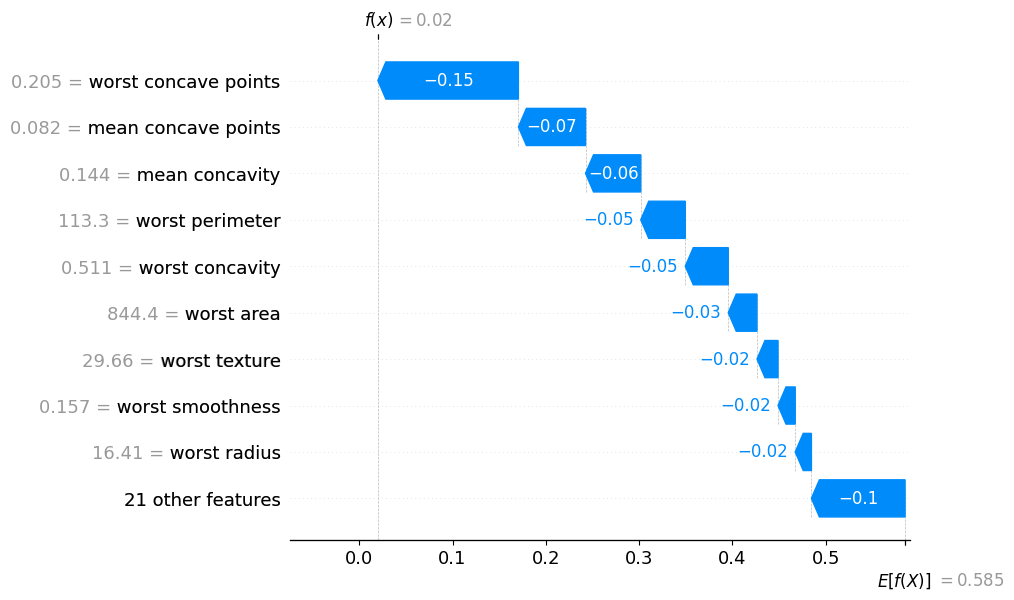

In [ ]:


shap.plots.waterfall(shap_values[0, :, 1])

## Key insights
- LIME: local surrogate model
- Kernel SHAP: weighted linear model with Shapley kernel
- Both rely on perturbations
- Kernel SHAP is slower but theoretically grounded
